**Import Library**

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

Library digunakan untuk pengolahan data, visualisasi, serta pembuatan model machine learning.

Scikit-learn digunakan karena menyediakan algoritma klasifikasi siap pakai.

**Load Dataset**

In [72]:
data = pd.read_csv('/content/data_ecommerce_customer_churn.csv')

data.head()

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0
1,7.0,25.0,4,Mobile,1,Married,2,0,7.0,129.29,0
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0
3,20.0,25.0,4,Fashion,3,Divorced,7,0,NaN,230.27,0
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0


**Data Understanding**

In [73]:
print("Jumlah Data :", data.shape)
data.info()

# cek missing value
print("\nMissing Value:")
print(data.isnull().sum())

Jumlah Data : (3941, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3941 entries, 0 to 3940
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Tenure                    3747 non-null   float64
 1   WarehouseToHome           3772 non-null   float64
 2   NumberOfDeviceRegistered  3941 non-null   int64  
 3   PreferedOrderCat          3941 non-null   object 
 4   SatisfactionScore         3941 non-null   int64  
 5   MaritalStatus             3941 non-null   object 
 6   NumberOfAddress           3941 non-null   int64  
 7   Complain                  3941 non-null   int64  
 8   DaySinceLastOrder         3728 non-null   float64
 9   CashbackAmount            3941 non-null   float64
 10  Churn                     3941 non-null   int64  
dtypes: float64(4), int64(5), object(2)
memory usage: 338.8+ KB

Missing Value:
Tenure                      194
WarehouseToHome             169
NumberOfD

Digunakan untuk mengetahui tipe data setiap variabel.
Mengecek apakah terdapat missing value sebelum proses modeling.

**Visualisasi Data (KORELASI)**

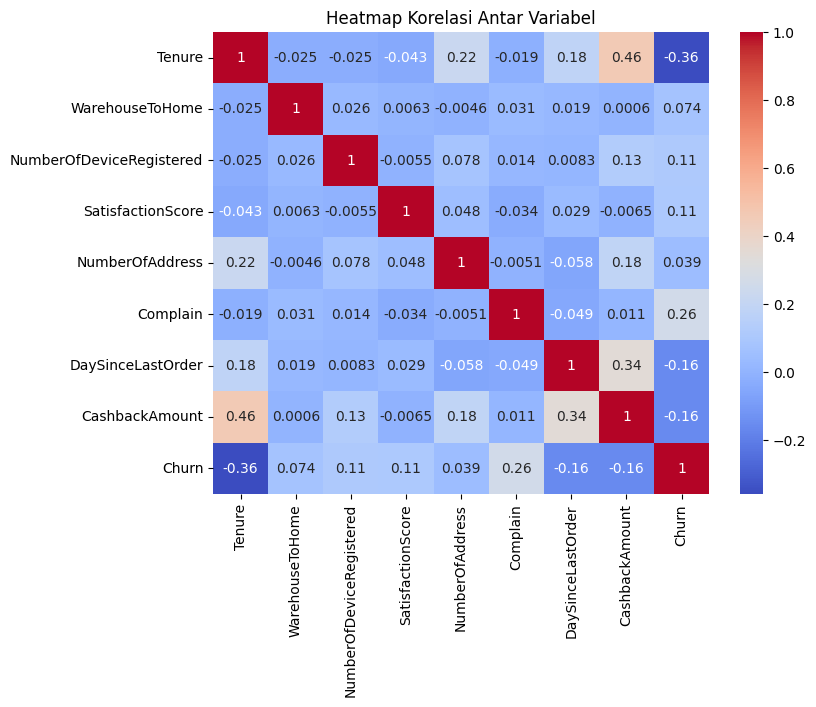

In [74]:
plt.figure(figsize=(8,6))

sns.heatmap(
    data.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Heatmap Korelasi Antar Variabel")
plt.show()

Heatmap menunjukkan hubungan antar variabel. Variabel yang paling berpengaruh terhadap churn adalah Tenure dengan korelasi negatif, artinya pelanggan yang lebih lama cenderung tidak churn, serta Complain yang memiliki korelasi positif sehingga pelanggan yang sering komplain lebih berpotensi churn.

**Encoding**

In [75]:
data = pd.get_dummies(data, drop_first=True)

data.head()

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile,PreferedOrderCat_Mobile Phone,PreferedOrderCat_Others,MaritalStatus_Married,MaritalStatus_Single
0,15.0,29.0,4,3,2,0,7.0,143.32,0,False,True,False,False,False,False,True
1,7.0,25.0,4,1,2,0,7.0,129.29,0,False,False,True,False,False,True,False
2,27.0,13.0,3,1,5,0,7.0,168.54,0,False,True,False,False,False,True,False
3,20.0,25.0,4,3,7,0,NaN,230.27,0,False,False,False,False,False,False,False
4,30.0,15.0,4,4,8,0,8.0,322.17,0,False,False,False,False,True,False,True


Meskipun beberapa variabel telah direpresentasikan dalam bentuk numerik, seperti PreferedOrderCat dan MaritalStatus, variabel tersebut sebenarnya bersifat kategorikal sehingga tetap memerlukan proses encoding agar tidak menimbulkan interpretasi urutan oleh model.

**Pemisahan Feature dan Target**

In [76]:
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

print("Shape Feature :", X.shape)
print("Shape Target :", y.shape)

Shape Feature : (3941, 15)
Shape Target : (3941,)


Dataset dipisahkan menjadi feature dan target. Feature terdiri dari 10 variabel independen yang digunakan sebagai input model, sedangkan target merupakan variabel Churn yang akan diprediksi. Jumlah data yang digunakan sebanyak 3941 observasi.

**Handle Missing Value (Median)**

In [77]:
from sklearn.impute import SimpleImputer

# Impute missing values with the median strategy
imputer = SimpleImputer(strategy='median')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

print("Missing values after imputation:")
print(X.isnull().sum())

Missing values after imputation:
Tenure                                 0
WarehouseToHome                        0
NumberOfDeviceRegistered               0
SatisfactionScore                      0
NumberOfAddress                        0
Complain                               0
DaySinceLastOrder                      0
CashbackAmount                         0
Churn                                  0
PreferedOrderCat_Grocery               0
PreferedOrderCat_Laptop & Accessory    0
PreferedOrderCat_Mobile                0
PreferedOrderCat_Mobile Phone          0
PreferedOrderCat_Others                0
MaritalStatus_Married                  0
dtype: int64


Setelah dilakukan imputasi menggunakan median, seluruh variabel sudah tidak memiliki missing value sehingga dataset siap digunakan pada tahap modeling tanpa risiko error akibat data kosong.

**Split Data**

In [78]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (3152, 15)
Test : (789, 15)


Dataset dibagi menjadi data training sebesar 80% dan data testing sebesar 20%. Data training digunakan untuk melatih model klasifikasi, sedangkan data testing digunakan untuk mengevaluasi kemampuan model dalam melakukan prediksi pada data baru yang belum pernah dilihat sebelumnya.

random_state digunakan agar proses pembagian data dapat direproduksi sehingga hasil eksperimen tetap konsisten.

**Feature Scaling**

In [79]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ubah ke dataframe biar bisa describe
X_train = pd.DataFrame(X_train, columns=X.columns)
X_test = pd.DataFrame(X_test, columns=X.columns)

# tampilkan statistik scaling
X_train.describe().T

,count,mean,std,min,25%,50%,75%,max
Tenure,3152.0,-5.410224e-17,1.000159,-1.203632,-0.841543,-0.117365,0.606813,6.038147
WarehouseToHome,3152.0,8.566188e-17,1.000159,-1.266525,-0.788845,-0.191746,0.524773,13.302697
NumberOfDeviceRegistered,3152.0,1.797772e-16,1.000159,-2.657121,-0.673641,0.318099,0.318099,2.301579
SatisfactionScore,3152.0,1.916121e-17,1.000159,-1.516372,-0.790209,-0.064046,0.662117,1.388280
NumberOfAddress,3152.0,6.762780e-17,1.000159,-1.233600,-0.849949,-0.466297,0.684657,6.823080
Complain,3152.0,7.777197e-17,1.000159,-0.634633,-0.634633,-0.634633,1.575713,1.575713
DaySinceLastOrder,3152.0,-5.184798e-17,1.000159,-1.237779,-0.680862,-0.402404,0.711429,11.571302
CashbackAmount,3152.0,2.907995e-16,1.000159,-3.581394,-0.634983,-0.285084,0.388379,3.002110
Churn,3152.0,-4.057668e-17,1.000159,-0.457223,-0.457223,-0.457223,-0.457223,2.187118
PreferedOrderCat_Grocery,3152.0,1.352556e-17,1.000159,-0.271910,-0.271910,-0.271910,-0.271910,3.677682


Berdasarkan hasil feature scaling menggunakan StandardScaler, seluruh variabel memiliki nilai rata-rata (mean) mendekati 0 dan standar deviasi (std) mendekati 1. Hal ini menunjukkan bahwa proses normalisasi telah berhasil dilakukan sehingga setiap variabel berada pada skala yang sama.

**Model 1 - Naive Bayes**

In [80]:
nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

print("Akurasi Naive Bayes:",
      accuracy_score(y_test, y_pred_nb))

Akurasi Naive Bayes: 0.8542458808618505


Berdasarkan hasil pemodelan menggunakan algoritma Naive Bayes, diperoleh nilai akurasi sebesar 86,18%. Hal ini menunjukkan bahwa model mampu mengklasifikasikan data pelanggan dengan tingkat ketepatan yang cukup tinggi. Dengan demikian, Naive Bayes dapat digunakan sebagai model awal dalam memprediksi kemungkinan pelanggan mengalami churn.

**Evaluasi Naive Bayes**


Classification Report:
              precision    recall  f1-score   support

       False       1.00      0.77      0.87       511
        True       0.71      1.00      0.83       278

    accuracy                           0.85       789
   macro avg       0.85      0.89      0.85       789
weighted avg       0.90      0.85      0.86       789



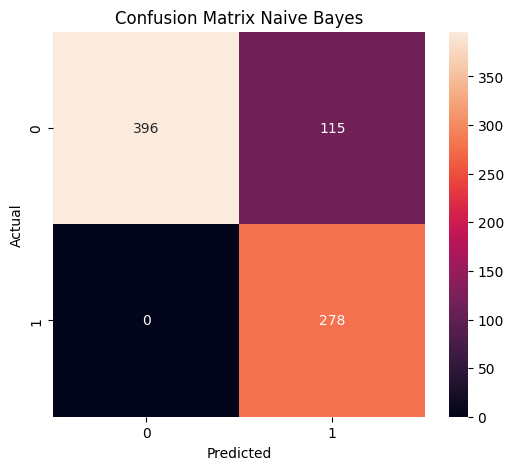

In [81]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))

cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(6,5))
sns.heatmap(cm_nb, annot=True, fmt='d')
plt.title("Confusion Matrix Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Berdasarkan confusion matrix, model mampu mengklasifikasikan pelanggan non-churn dengan sangat baik sebanyak 613 data benar. Namun masih terdapat 62 pelanggan churn yang gagal terdeteksi. Hal ini menunjukkan model memiliki akurasi tinggi tetapi sensitivitas terhadap churn masih perlu ditingkatkan.

**Model 2 - KNN**

In [82]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print("Akurasi KNN:",
      accuracy_score(y_test, y_pred_knn))

Akurasi KNN: 0.8555133079847909


Berdasarkan hasil pemodelan, algoritma KNN memperoleh akurasi sebesar 89,48%, lebih tinggi dibandingkan Naive Bayes sebesar 86,18%. Hal ini menunjukkan bahwa KNN lebih efektif dalam mengklasifikasikan pelanggan churn pada dataset yang digunakan.

**Evaluasi KNN**


Classification Report:
              precision    recall  f1-score   support

       False       0.92      0.85      0.88       511
        True       0.76      0.87      0.81       278

    accuracy                           0.86       789
   macro avg       0.84      0.86      0.85       789
weighted avg       0.86      0.86      0.86       789



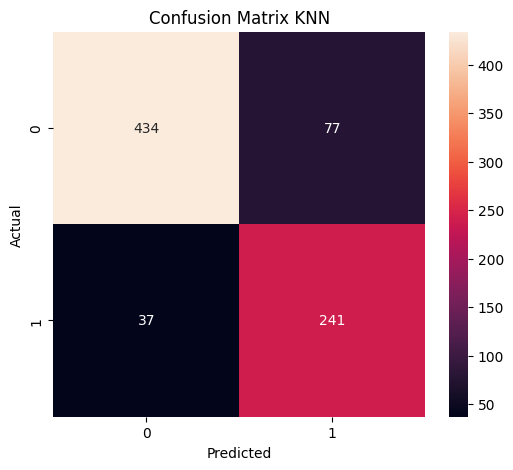

In [83]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6,5))
sns.heatmap(cm_knn, annot=True, fmt='d')
plt.title("Confusion Matrix KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Berdasarkan evaluasi model KNN diperoleh akurasi sebesar 89%. Model sangat baik dalam mengidentifikasi pelanggan non-churn, namun kemampuan mendeteksi pelanggan churn masih terbatas dengan nilai recall sebesar 47%. Hal ini menunjukkan adanya ketidakseimbangan data antara kelas churn dan non-churn.


Jumlah data pelanggan churn lebih sedikit sehingga model cenderung belajar pola kelas mayoritas.

**Elbow Method untuk Menetukan K Optimal**

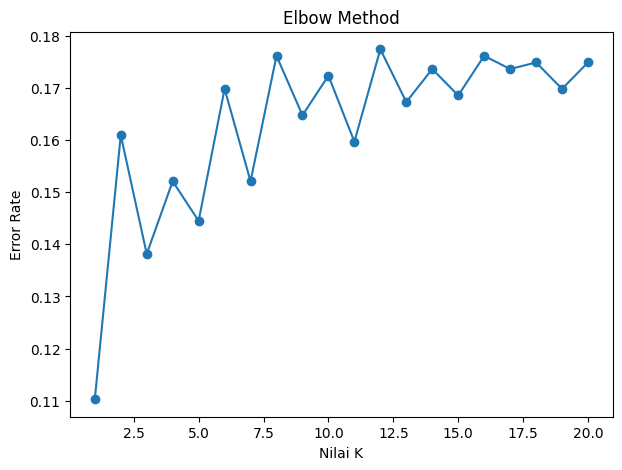

In [84]:
error_rate = []

for k in range(1,21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train,y_train)
    pred_k = knn.predict(X_test)
    error_rate.append(np.mean(pred_k != y_test))

plt.figure(figsize=(7,5))
plt.plot(range(1,21), error_rate, marker='o')

plt.title("Elbow Method")
plt.xlabel("Nilai K")
plt.ylabel("Error Rate")
plt.show()

Berdasarkan grafik Elbow Method, nilai error rate mengalami penurunan signifikan hingga K = 5 dan setelahnya cenderung stabil. Oleh karena itu, nilai K optimal yang dipilih pada model K-Nearest Neighbor adalah K = 5.

**Perbandingan Model**

In [85]:
 acc_nb = accuracy_score(y_test, y_pred_nb)
acc_knn = accuracy_score(y_test, y_pred_knn)

hasil = pd.DataFrame({
    "Model":["Naive Bayes","KNN"],
    "Accuracy":[acc_nb, acc_knn]
})

hasil

,Model,Accuracy
0,Naive Bayes,0.854246
1,KNN,0.855513


Berdasarkan hasil evaluasi, model K-Nearest Neighbor (KNN) dipilih sebagai model terbaik karena memiliki nilai akurasi tertinggi yaitu sebesar 89,48%, sehingga lebih optimal digunakan dalam prediksi customer churn dibandingkan model Naive Bayes.

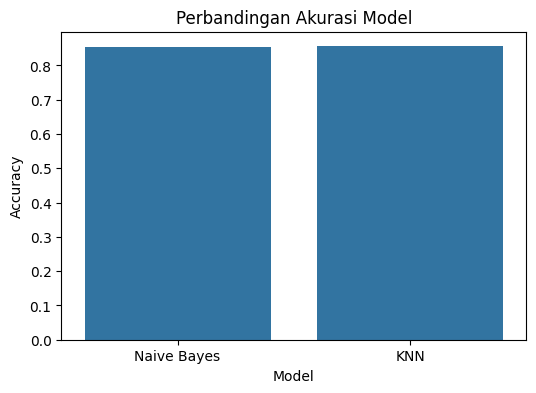

In [86]:
plt.figure(figsize=(6,4))

sns.barplot(data=hasil, x="Model", y="Accuracy")

plt.title("Perbandingan Akurasi Model")
plt.show()

Berdasarkan visualisasi perbandingan akurasi model, metode K-Nearest Neighbor (KNN) dipilih sebagai model terbaik karena menghasilkan tingkat akurasi tertinggi dalam prediksi customer churn.

**Analisis Data Salah Prediksi KNN**

In [87]:
mask_salah = y_test.values != y_pred_knn

data_salah = X_test[mask_salah].copy()

data_salah['Actual'] = y_test.values[mask_salah]
data_salah['Predicted'] = y_pred_knn[mask_salah]

print("Jumlah data salah prediksi:", len(data_salah))
data_salah.head()

Jumlah data salah prediksi: 114


,Tenure,WarehouseToHome,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile,PreferedOrderCat_Mobile Phone,PreferedOrderCat_Others,MaritalStatus_Married,Actual,Predicted
2,0.003331,0.644193,0.318099,-0.790209,-0.849949,1.575713,2.103720,0.284964,-0.457223,-0.27191,1.323948,-0.407039,-0.543128,-0.222749,-1.054128,False,True
5,0.486117,2.077231,0.318099,1.388280,-0.466297,-0.634633,0.432971,0.651626,-0.457223,-0.27191,1.323948,-0.407039,-0.543128,-0.222749,-1.054128,False,True
11,0.003331,-0.550006,-2.657121,-0.064046,-1.233600,-0.634633,-0.402404,-0.846624,-0.457223,-0.27191,-0.755317,2.456769,-0.543128,-0.222749,-1.054128,True,False
19,-0.117365,1.002452,0.318099,1.388280,0.301006,1.575713,-0.402404,0.767094,-0.457223,-0.27191,1.323948,-0.407039,-0.543128,-0.222749,-1.054128,False,True
22,-0.479454,-0.191746,-0.673641,0.662117,-0.466297,-0.634633,-0.123946,-0.483203,-0.457223,-0.27191,-0.755317,-0.407039,1.841188,-0.222749,-1.054128,False,True


Kesalahan prediksi terjadi karena beberapa pelanggan memiliki pola perilaku yang mirip antara churn dan tidak churn. Model KNN berbasis jarak sehingga ketika data berada di area batas kelas, model sulit membedakan keduanya.

Tabel salah prediksi menampilkan data pelanggan yang tidak berhasil diklasifikasikan dengan benar oleh model KNN. Nilai fitur pada tabel merupakan hasil feature scaling, sehingga nilai positif menunjukkan nilai di atas rata-rata dan nilai negatif menunjukkan nilai di bawah rata-rata. Kesalahan prediksi terjadi karena beberapa pelanggan memiliki karakteristik yang mirip antara pelanggan churn dan tidak churn sehingga model mengalami kesulitan dalam melakukan klasifikasi.

**Decision Boundary KNN**

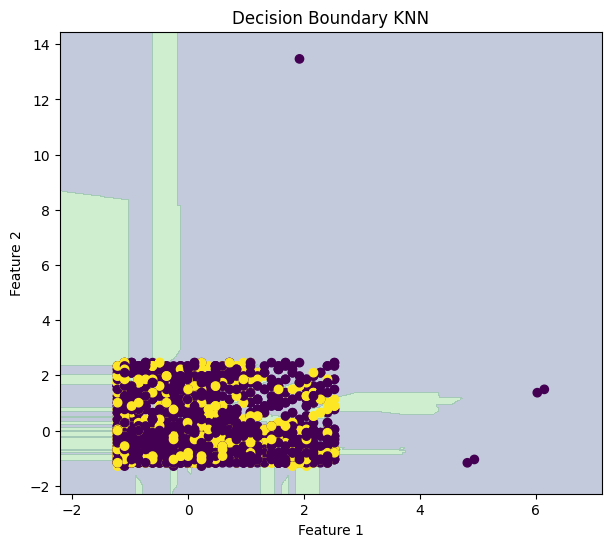

In [88]:
# ambil 2 fitur pertama untuk visualisasi
X_vis = X_scaled.iloc[:,0:2]
y_vis = y

scaler_vis = StandardScaler()
X_vis_scaled = scaler_vis.fit_transform(X_vis)

knn_vis = KNeighborsClassifier(n_neighbors=5)
knn_vis.fit(X_vis_scaled, y_vis)

# membuat grid
x_min, x_max = X_vis_scaled[:,0].min()-1, X_vis_scaled[:,0].max()+1
y_min, y_max = X_vis_scaled[:,1].min()-1, X_vis_scaled[:,1].max()+1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

Z = knn_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(7,6))

plt.contourf(xx, yy, Z, alpha=0.3)

plt.scatter(
    X_vis_scaled[:,0],
    X_vis_scaled[:,1],
    c=y_vis
)

plt.title("Decision Boundary KNN")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

Decision boundary pada KNN menunjukkan bahwa model membagi ruang fitur berdasarkan kedekatan antar data. Namun, terlihat adanya overlap antar kelas dan outlier, yang menyebabkan model berpotensi melakukan kesalahan klasifikasi pada beberapa titik data.

**Visualisasi Perbandingan Model**

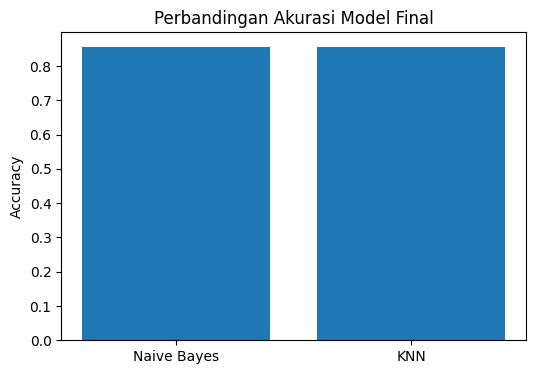

In [89]:
models = ["Naive Bayes","KNN"]
scores = [acc_nb, acc_knn]

plt.figure(figsize=(6,4))
plt.bar(models, scores)

plt.title("Perbandingan Akurasi Model Final")
plt.ylabel("Accuracy")

plt.show()

Berdasarkan hasil perbandingan, KNN memberikan akurasi yang lebih tinggi dibandingkan Naive Bayes, namun pemilihan model terbaik tetap harus mempertimbangkan karakteristik data dan kebutuhan komputasi.